# Fake News Prediction

## Team Members 

- Nathan Ford - X00229157
- Cody Juthan - X00221674
- Reece Lawlor Driver - X00220250

# Project Summary

### Import Required Libraries

We import essential Python libraries for working with data, visualisation, and machine learning model development. This supports repeatability and establishes our technical environment for the project.

In [26]:
import numpy as np
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



## Dataset Details
Here we will be using feature selection on each individual dataset so that we may join them and use them as one big dataset.
We will then clean our data by ensuring there are no duplicates, null values etc

### First dataset 
Source: Kaggle Fake News Dataset (https://www.kaggle.com/code/anshahluwalia14/fake-news-detection/input)

Features: title, text, subject, date

License: Public dataset 

In [27]:
#Read in csv file as strings
fake = pd.read_csv("REAL DATASETS/fakenewsdata/True.csv") 
real = pd.read_csv("REAL DATASETS/fakenewsdata/Fake.csv")

merged_files = pd.concat([fake, real], ignore_index=True)
merged_files.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


### Second dataset:
Fake news dataset source: https://www.kaggle.com/datasets/amar5693/fake-and-real-news-dataset-4k


In [28]:
second_data = pd.read_csv("REAL DATASETS/fake_news_dataset_4000_rows.csv", dtype=str)
second_data.head()

,id,title,text,author,source,topic,publish_date,year,month,day,word_count,char_count,title_length,label
0,1,Miracle Cure Update 1,This article discusses Miracle Cure Update 1. ...,Guest Writer,ViralNow,Miracle Cure,2023-09-30,2023,9,30,32,219,21,0
1,2,Conspiracy Update 2,This article discusses Conspiracy Update 2. Ho...,Unknown Reporter,RumorTimes,Conspiracy,2024-07-29,2024,7,29,31,217,19,0
2,3,Technology Update 3,This article discusses Technology Update 3. Th...,Ayesha Khan,BBC News,Technology,2023-05-19,2023,5,19,29,210,19,1
3,4,Economy Update 4,This article discusses Economy Update 4. The i...,Fatima Noor,Al Jazeera,Economy,2023-09-09,2023,9,9,29,207,16,1
4,5,Conspiracy Update 5,This article discusses Conspiracy Update 5. Ho...,Anonymous,RumorTimes,Conspiracy,2024-09-03,2024,9,3,31,217,19,0


As we can see the second dataset is very different to the first. If we are to train all this data together me must make them similar. 
To do this we will drop all but four columns and rename them so they may work alongside our other datasets

In [29]:
#Choosing the columns we will be working with
second_data = second_data[["title", "text", "topic", "publish_date"]]

#Renaming feature columns so they align with our other datasets
second_data = second_data.rename(columns={"topic" : "subject",
                                          "publish_date" : "date"})

second_data.head()

,title,text,subject,date
0,Miracle Cure Update 1,This article discusses Miracle Cure Update 1. ...,Miracle Cure,2023-09-30
1,Conspiracy Update 2,This article discusses Conspiracy Update 2. Ho...,Conspiracy,2024-07-29
2,Technology Update 3,This article discusses Technology Update 3. Th...,Technology,2023-05-19
3,Economy Update 4,This article discusses Economy Update 4. The i...,Economy,2023-09-09
4,Conspiracy Update 5,This article discusses Conspiracy Update 5. Ho...,Conspiracy,2024-09-03


### Third dataset
Dataset source: 

In [30]:
third_data = pd.read_csv("REAL DATASETS/fake_news_dataset1.csv", dtype=str)
third_data.head()

,title,text,date,source,author,category,label
0,Foreign Democrat final.,more tax development both store agreement lawy...,2023-03-10,NY Times,Paula George,Politics,real
1,To offer down resource great point.,probably guess western behind likely next inve...,2022-05-25,Fox News,Joseph Hill,Politics,fake
2,Himself church myself carry.,them identify forward present success risk sev...,2022-09-01,CNN,Julia Robinson,Business,fake
3,You unit its should.,phone which item yard Republican safe where po...,2023-02-07,Reuters,Mr. David Foster DDS,Science,fake
4,Billion believe employee summer how.,wonder myself fact difficult course forget exa...,2023-04-03,CNN,Austin Walker,Technology,fake


In [31]:
#Choosing the columns we would like to work with
third_data = third_data[["title", "text", "date", "category"]]

#Renaming category to subject
third_data = third_data.rename(columns={"category" : "subject"})

third_data.head()

,title,text,date,subject
0,Foreign Democrat final.,more tax development both store agreement lawy...,2023-03-10,Politics
1,To offer down resource great point.,probably guess western behind likely next inve...,2022-05-25,Politics
2,Himself church myself carry.,them identify forward present success risk sev...,2022-09-01,Business
3,You unit its should.,phone which item yard Republican safe where po...,2023-02-07,Science
4,Billion believe employee summer how.,wonder myself fact difficult course forget exa...,2023-04-03,Technology


As we can see all the datasets now have matching feature columns, this means we can join them to make one big dataset.

In [32]:
#This will use pandas to join all the datasets and ignore headers
data = pd.concat([merged_files, second_data, third_data], ignore_index=True)

## 1. Data cleaning and wrangling

Following best-practice guidelines, we check for:
- Missing values
- Duplicate records
- Incorrect or extreme values
- Data types


In [33]:
# Missing values summary
data.isna().sum()


title      0
text       0
subject    0
date       0
dtype: int64

There's zero missing values in all columns

### Checked to see if there is any duplicate data

In [34]:
#Detect any duplicate rows and drop them
duplicates = data.duplicated().sum()
print("Duplicate rows:", duplicates)

print("Data shape before dropping duplicates:", data.shape)


if duplicates > 0:
    data = data.drop_duplicates()

print(f"\nData shape after dropping duplicates:", data.shape)


Duplicate rows: 209
Data shape before dropping duplicates: (68898, 4)

Data shape after dropping duplicates: (68689, 4)


There were 209 duplicated rows so we dropped them.

In [35]:
data.describe()


,title,text,subject,date
count,68689,68689,68689,68689
unique,62729,62646,23,3493
top,Factbox: Trump fills top jobs for his administ...,,politicsNews,"December 6, 2017"
freq,14,627,11220,166


# 2. Feature Selection and Pre Processing

In [36]:

# Check original shape
print("Data shape before processing:", data.shape)

# Define features (X) and target (y)
X = data[["title", "text", "date"]]   # input features
y = data["subject"]                  # target label

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Data shape before processing: (68689, 4)
Feature shape: (68689, 3)
Target shape: (68689,)


# Graphing the data

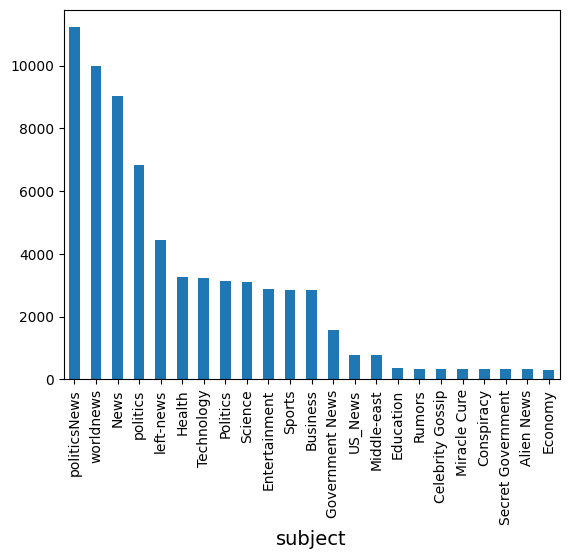

In [37]:
data["subject"].value_counts().plot(kind="bar")

plt.show()

This graph highlights the number of articles relating to each news subject

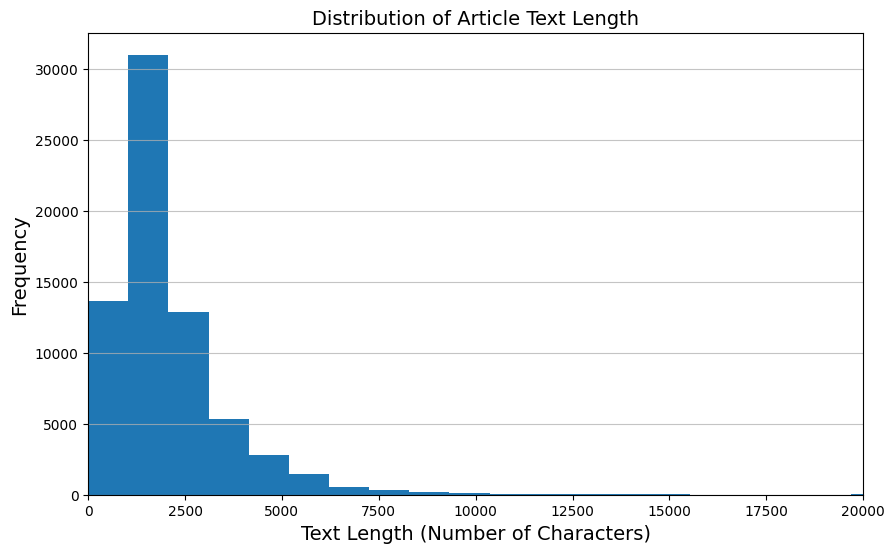

In [ ]:
plt.figure(figsize=(10,6))
plt.hist(data["text_length"], bins=50)

plt.xlabel("Text Length (Number of Characters)")
plt.ylabel("Frequency")
plt.title("Distribution of Article Text Length")

plt.xlim(0, 20000)  

plt.grid(axis="y", alpha=0.75)
plt.show()

This graph displays the text length of the articles 

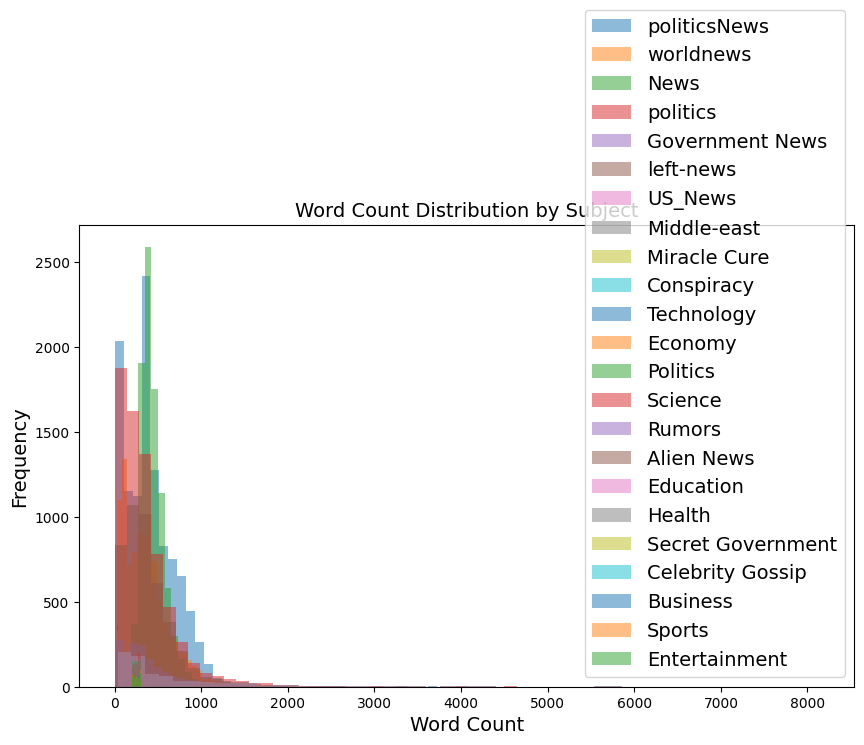

In [49]:
data["word_count"] = data["text"].str.split().str.len()

plt.figure(figsize=(10,6))

for label in data["subject"].unique():
    subset = data[data["subject"] == label]
    plt.hist(subset["word_count"], bins=50, alpha=0.5, label=label)

plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.title("Word Count Distribution by Subject")
plt.legend()
plt.show()

This graph showcases the frequency of each subject in our dataset